# BinWaves example in Cantabria (Validation)

**In this notebook**: 
<br><br>
Here waves are reconstructed at the buoy location for comparison.
<br><br>
Steps:
- Buoy is loaded.
- Kp propagation coefficients and hindcast reconstruction is made at the buoy location.
- Comparison plots and statistics are shown.

**In this notebook**: 
<br><br>
Here waves are reconstructed at the buoy location for comparison.
<br><br>
Steps:
- Buoy is loaded.
- Kp propagation coefficients and hindcast reconstruction is made at the buoy location.
- Comparison plots and statistics are shown.

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
from utils.operations import transform_ERA5_spectrum
from bluemath_tk.waves.binwaves import reconstruc_spectra
from utils.plotting import plot_wave_series
import dask
dask.config.set({"distributed.comm.timeouts.connect": "60s"})

# Dictionary mapping buoy IDs to their coordinates
BUOY_COORDS = {
    '44088': {'lon': 285.161, 'lat': 36.6120},
    '44100': {'lon': 284.407, 'lat': 36.2580},
    '44056': {'lon': 284.286, 'lat': 36.2000},
    '41120': {'lon': 284.715, 'lat': 35.2580},
    '41025': {'lon': 284.546, 'lat': 35.0100},
    '44095': {'lon': 284.67, 'lat': 35.7500},
    '44086': {'lon': 284.579, 'lat': 36.0010}
}

# Load all kp coefficients
kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
print(f"Number of sites in kp_coeffs: {len(kp_coeffs.site)}")
print(f"UTM coordinates for each site:")
for i in range(len(kp_coeffs.site)):
    print(f"Site {i}: x={kp_coeffs.utm_x.values[i]}, y={kp_coeffs.utm_y.values[i]}")

# Load model parameters and offshore spectra
model_parameters = pd.read_csv("NC_cases/swan_cases.csv").to_dict(orient="list")
offshore_spectra, offshore_spectra_case = transform_ERA5_spectrum(
    era5_spectrum=xr.open_dataset("outputs/jen_north_carolina_spec_utm_unique.nc"),
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
)

Number of sites in kp_coeffs: 6
UTM coordinates for each site:
Site 0: x=514397.61, y=4051843.74
Site 1: x=446728.66, y=4012728.08
Site 2: x=462056.64, y=3984141.31
Site 3: x=435811.25, y=4006367.97
Site 4: x=470164.24, y=3956270.58
Site 5: x=458576.64, y=3874246.18


/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/core/accessor_dt.py:163: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  field_values = method(freq=freq).values


In [2]:
# Add this in a new cell before the reconstruction loop
def validate_data(buoy_waves, site_kp_coeffs, offshore_data):
    """Validate data before reconstruction"""
    if buoy_waves.isna().any().any():
        print(f"Warning: Buoy data contains NaN values")
        buoy_waves = buoy_waves.fillna(method='ffill').fillna(method='bfill')
        
    if site_kp_coeffs.isnull().any():
        print(f"Warning: Kp coefficients contain NaN values")
        raise ValueError("Kp coefficients contain NaN values")
        
    if offshore_data.isnull().any():
        print(f"Warning: Offshore spectra contains NaN values")
        raise ValueError("Offshore spectra contains NaN values")
        
    return buoy_waves

# Process each site
# Process each site
for site_idx, buoy_id in enumerate(BUOY_COORDS.keys()):
    print(f"\nProcessing buoy {buoy_id} (site index {site_idx})")
    
    try:
        # Get coordinates for this buoy
        coords = BUOY_COORDS[buoy_id]
        
        # Set coordinates for this site
        offshore_spectra_case.coords['longitude'] = np.float32(coords['lon'])
        offshore_spectra_case.coords['latitude'] = np.float32(coords['lat'])
        
        # Add attributes to the coordinates
        offshore_spectra_case.coords['longitude'].attrs = {
            'units': 'degrees_east',
            'long_name': 'Longitude'
        }
        offshore_spectra_case.coords['latitude'].attrs = {
            'units': 'degrees_north',
            'long_name': 'Latitude'
        }
        
        # Load buoy data
        buoy_waves = pd.read_pickle(f"outputs/buoy_{buoy_id}_bulk_parameters.pkl").sort_index().loc["2022"]
        
        # Get kp coefficients for this site
        site_kp_coeffs = kp_coeffs.isel(site=[site_idx])
        
        # Get offshore data
        offshore_data = offshore_spectra_case.sel(time=buoy_waves.index, method="nearest")
        
        # Validate data
        buoy_waves = validate_data(buoy_waves, site_kp_coeffs, offshore_data)
        
        # Reconstruct spectra
        reconstructed_onshore_spectra = reconstruc_spectra(
            offshore_spectra=offshore_data,
            kp_coeffs=site_kp_coeffs,
        )
        
        # Plot results
        plot_wave_series(
            buoy_data=buoy_waves,
            binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
            .squeeze()
            .drop_duplicates('time')
            .sel(time=buoy_waves.index, method="nearest")
            .spec,
            offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
            times=buoy_waves.index.values,
        )
    except Exception as e:
        print(f"Error processing buoy {buoy_id}: {str(e)}")


Processing buoy 44088 (site index 0)


/tmp/ipykernel_2400599/2045952641.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  buoy_waves = buoy_waves.fillna(method='ffill').fillna(method='bfill')


Error processing buoy 44088: Kp coefficients contain NaN values

Processing buoy 44100 (site index 1)
Error processing buoy 44100: Kp coefficients contain NaN values

Processing buoy 44056 (site index 2)


/tmp/ipykernel_2400599/2045952641.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  buoy_waves = buoy_waves.fillna(method='ffill').fillna(method='bfill')


Error processing buoy 44056: Kp coefficients contain NaN values

Processing buoy 41120 (site index 3)
Error processing buoy 41120: Kp coefficients contain NaN values

Processing buoy 41025 (site index 4)


/tmp/ipykernel_2400599/2045952641.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  buoy_waves = buoy_waves.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_2400599/2045952641.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  buoy_waves = buoy_waves.fillna(method='ffill').fillna(method='bfill')


Error processing buoy 41025: Kp coefficients contain NaN values

Processing buoy 44095 (site index 5)
Error processing buoy 44095: Kp coefficients contain NaN values

Processing buoy 44086 (site index 6)


/tmp/ipykernel_2400599/2045952641.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  buoy_waves = buoy_waves.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_2400599/2045952641.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  buoy_waves = buoy_waves.fillna(method='ffill').fillna(method='bfill')


Error processing buoy 44086: index 6 is out of bounds for axis 0 with size 6


In [3]:
from utils.plotting import plot_wave_series

# Plot reconstructed bulk parameters vs buoy data

# plot_wave_series(
#     buoy_data=buoy_waves,
#     binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
#     .squeeze()
#     .sel(time=buoy_waves.index, method="nearest")
#     .spec,
#     offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
#     times=buoy_waves.index.values,
# )
# Plot reconstructed bulk parameters vs buoy data
plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
    .squeeze()
    .drop_duplicates('time')  # Add this line to remove duplicates
    .sel(time=buoy_waves.index, method="nearest")
    .spec,
    offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
    times=buoy_waves.index.values,
)

NameError: name 'reconstructed_onshore_spectra' is not defined

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


ValueError: array must not contain infs or NaNs

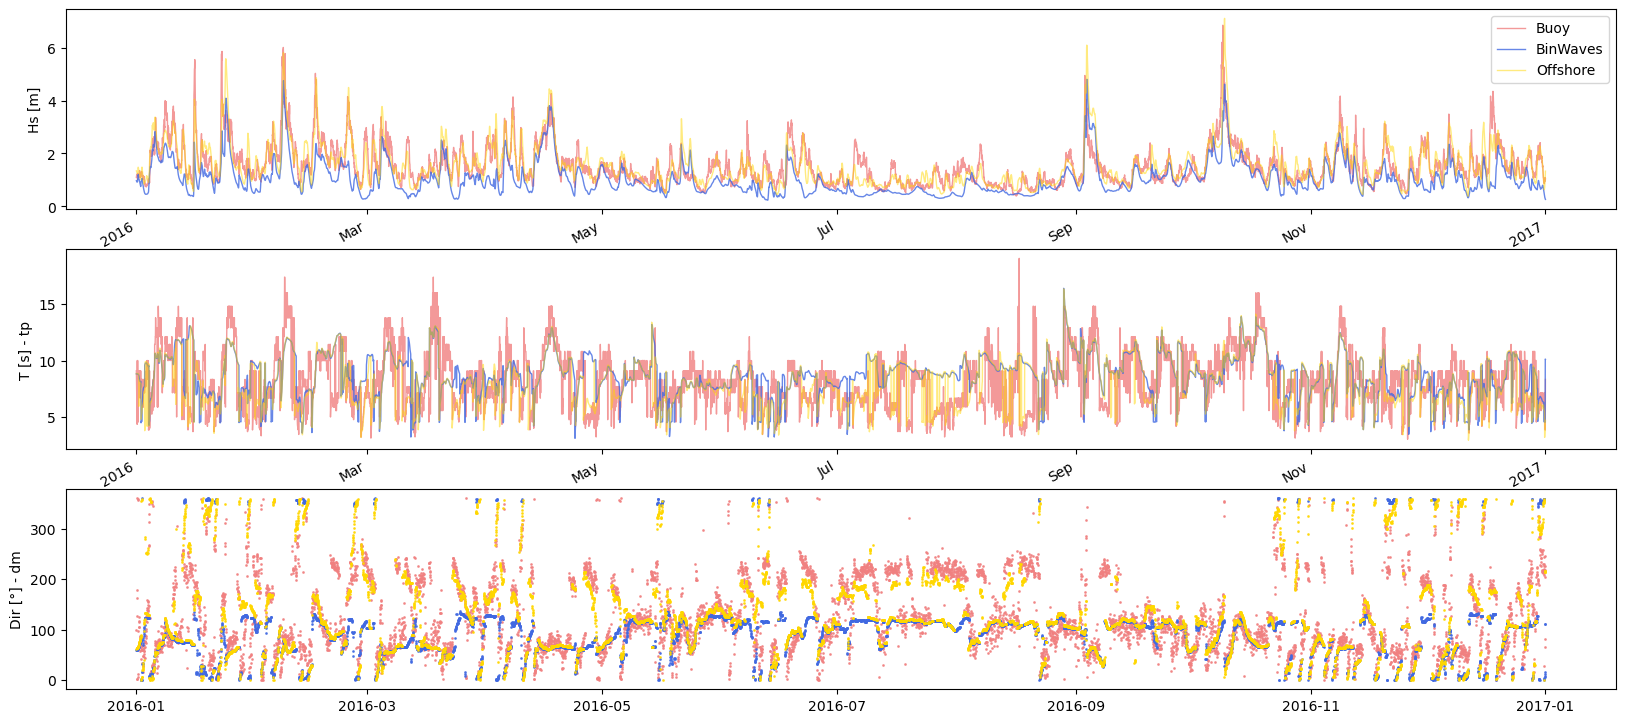

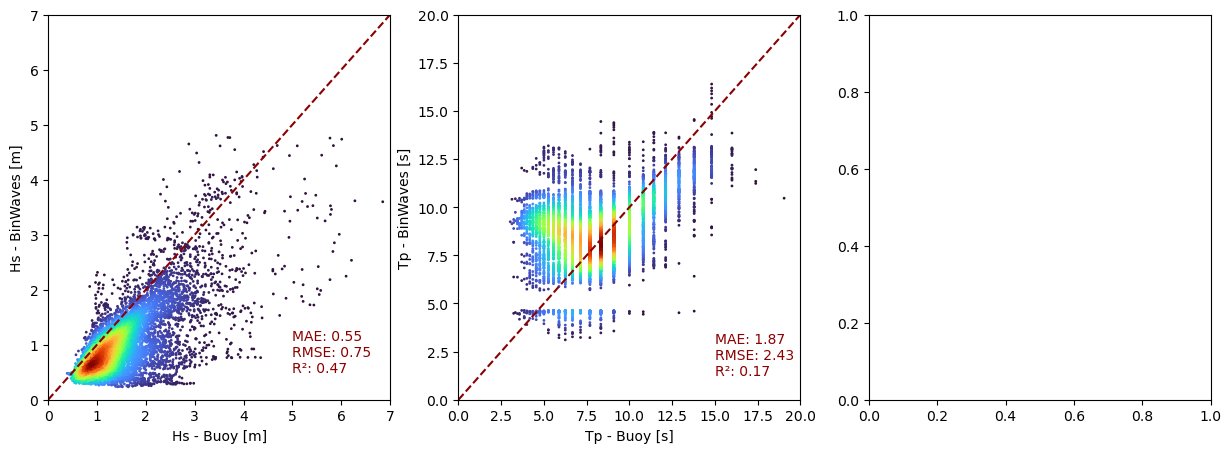

In [ ]:
from utils.plotting import plot_wave_series

# Plot reconstructed bulk parameters vs buoy data

# plot_wave_series(
#     buoy_data=buoy_waves,
#     binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
#     .squeeze()
#     .sel(time=buoy_waves.index, method="nearest")
#     .spec,
#     offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
#     times=buoy_waves.index.values,
# )
# Plot reconstructed bulk parameters vs buoy data
plot_wave_series(
    buoy_data=buoy_waves,
    binwaves_data=reconstructed_onshore_spectra.rename({"kps": "efth"})
    .squeeze()
    .drop_duplicates('time')  # Add this line to remove duplicates
    .sel(time=buoy_waves.index, method="nearest")
    .spec,
    offshore_data=offshore_spectra.sel(time=buoy_waves.index, method="nearest").spec,
    times=buoy_waves.index.values,
)